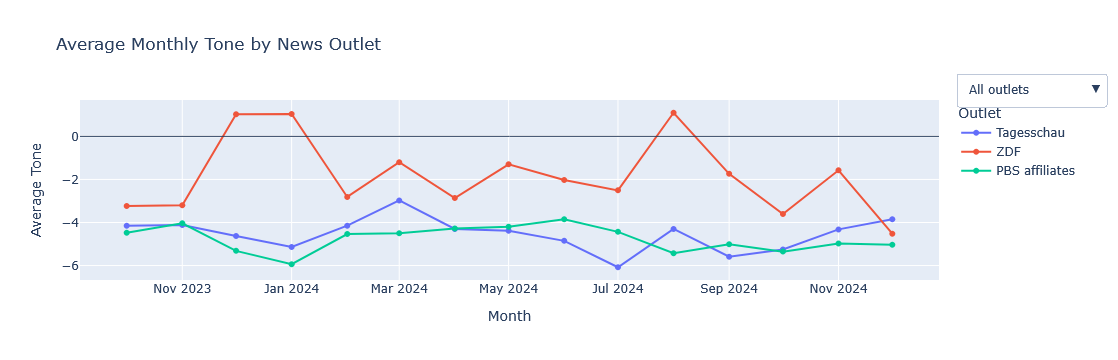

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import plotly.graph_objects as go

df = pd.read_csv(Path("tagesschau_zdf_pbs_foxnews_bild_gkg_partitioned_full.csv"))

def first_tone(x):
    try:
        return float(str(x).split(",")[0])
    except:
        return np.nan

df["tone"] = df["V2Tone"].map(first_tone)
df["date"] = pd.to_datetime(df["DATE"].astype(str), format="%Y%m%d%H%M%S", errors="coerce")

# news outlets
pbs_affiliates = {"pbs.org", "kpbs.org", "nhpbs.org", "azpbs.org"}

def outlet_group(src):
    if src == "tagesschau.de":
        return "Tagesschau"
    elif src == "zdf.de":
        return "ZDF"
    elif src in pbs_affiliates:
        return "PBS affiliates"
    return None

df["outlet_group"] = df["SourceCommonName"].map(outlet_group)

# filtering Israel-Palestine articles
url_col = "url" if "url" in df.columns else "DocumentIdentifier"

keywords = [
    "gaza", "palästina", "israel", "hamas", "palestine", "rafah",
    "Zwei-Staaten-Lösung", "two-state solution", "hamas-tunnel",
    "idf", "israel defense forces", "israelische verteidigungskräfte"
]

pattern = "|".join(keywords)

rq1 = df[
    df["outlet_group"].notna()
    & df[url_col].astype(str).str.contains(pattern, case=False, na=False, regex=True)
].copy()

rq1 = rq1.dropna(subset=["date", "tone"])
rq1 = rq1[(rq1["date"] >= "2023-10-08") & (rq1["date"] <= "2024-12-31")]

# monthly column
rq1["month"] = rq1["date"].dt.to_period("M").dt.to_timestamp()

# avg tone (monthly)
monthly_avg = (
    rq1.groupby(["month", "outlet_group"])["tone"]
    .mean()
    .reset_index(name="average_tone")
)

# article count (monthly)
monthly_count = (
    rq1.groupby(["month", "outlet_group"])
    .size()
    .reset_index(name="article_count")
)

# data merging
monthly = monthly_avg.merge(monthly_count, on=["month", "outlet_group"], how="left")

outlets = ["Tagesschau", "ZDF", "PBS affiliates"]

fig = go.Figure()

for outlet in outlets:
    sub = monthly[monthly["outlet_group"] == outlet]
    fig.add_trace(go.Scatter(
        x=sub["month"],
        y=sub["average_tone"],
        mode="lines+markers",
        name=outlet,
        customdata=sub[["article_count"]],
        hovertemplate=(
            f"<b>{outlet}</b><br>"
            "Month: %{x|%b %Y}<br>"
            "Average tone: %{y:.2f}<br>"
            "Article count: %{customdata[0]}<extra></extra>"
        )
    ))

fig.update_layout(
    title="Average Monthly Tone by News Outlet",
    xaxis_title="Month",
    yaxis_title="Average Tone",
    legend_title="Outlet",
    hovermode="x unified",
    updatemenus=[
        dict(
            buttons=[
                dict(
                    label="All outlets",
                    method="update",
                    args=[{"visible": [True, True, True]},
                          {"title": "Average Monthly Tone by News Outlet"}]
                ),
                dict(
                    label="Tagesschau only",
                    method="update",
                    args=[{"visible": [True, False, False]},
                          {"title": "Average Monthly Tone - Tagesschau"}]
                ),
                dict(
                    label="ZDF only",
                    method="update",
                    args=[{"visible": [False, True, False]},
                          {"title": "Average Monthly Tone - ZDF"}]
                ),
                dict(
                    label="PBS affiliates only",
                    method="update",
                    args=[{"visible": [False, False, True]},
                          {"title": "Average Monthly Tone - PBS affiliates"}]
                ),
            ],
            direction="down",
            showactive=True,
            x=1.02,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )
    ]
)

fig.add_hline(y=0, line_width=1)

fig.show()

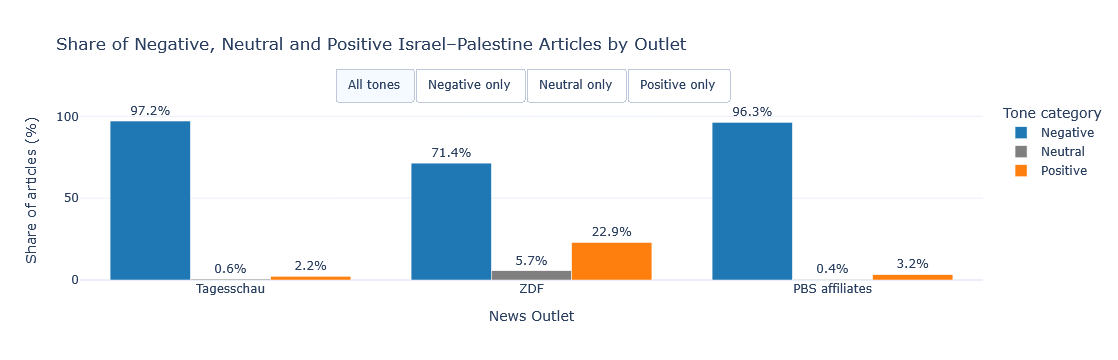

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import plotly.graph_objects as go

path = Path(r'tagesschau_zdf_pbs_foxnews_bild_gkg_partitioned_full.csv')
df = pd.read_csv(path)

def first_tone(x):
    try:
        return float(str(x).split(',')[0])
    except Exception:
        return np.nan

df['tone'] = df['V2Tone'].map(first_tone)
df['date'] = pd.to_datetime(df['DATE'].astype(str), format='%Y%m%d%H%M%S', errors='coerce')

# news outlets
pbs_affiliates = {'pbs.org', 'kpbs.org', 'nhpbs.org', 'azpbs.org'}

def outlet_group(src):
    if src == 'tagesschau.de':
        return 'Tagesschau'
    if src == 'zdf.de':
        return 'ZDF'
    if src in pbs_affiliates:
        return 'PBS affiliates'
    return None

df['outlet_group'] = df['SourceCommonName'].map(outlet_group)

# filtering Israel-Palestine articles
url_col = 'url' if 'url' in df.columns else 'DocumentIdentifier'

keywords = [
    "gaza", "palästina", "israel", "hamas", "palestine", "rafah",
    "Zwei-Staaten-Lösung", "two-state solution", "hamas-tunnel",
    "idf", "israel defense forces", "israelische verteidigungskräfte"
]

pattern = "|".join(re.escape(k) for k in keywords)

topic_mask = df[url_col].astype(str).str.contains(
    pattern,
    case=False,
    na=False,
    regex=True
)

rq1 = df[df['outlet_group'].notna() & topic_mask].copy()
rq1 = rq1.dropna(subset=['date', 'tone'])
rq1 = rq1[(rq1['date'] >= '2023-10-08') & (rq1['date'] <= '2024-12-31')].copy()

def tone_category(x):
    if x < 0:
        return 'Negative'
    elif x > 0:
        return 'Positive'
    return 'Neutral'

rq1['tone_category'] = rq1['tone'].apply(tone_category)

# total counts by each outlet
outlet_order = ['Tagesschau', 'ZDF', 'PBS affiliates']
tone_order = ['Negative', 'Neutral', 'Positive']

counts = rq1['outlet_group'].value_counts().reindex(outlet_order).fillna(0).astype(int)

# counts per outlet and tone
abs_counts = (
    rq1.groupby(['outlet_group', 'tone_category'])
      .size()
      .unstack(fill_value=0)
)

for col in tone_order:
    if col not in abs_counts.columns:
        abs_counts[col] = 0

abs_counts = abs_counts[tone_order].reindex(outlet_order).fillna(0).astype(int)

# percentage number
shares = abs_counts.div(abs_counts.sum(axis=1), axis=0) * 100
shares = shares.fillna(0)

x_labels = outlet_order

colors = {
    'Negative': '#1f77b4',
    'Neutral':  '#7f7f7f',
    'Positive': '#ff7f0e'
}

fig = go.Figure()

for tone in tone_order:
    fig.add_trace(go.Bar(
        x=x_labels,
        y=shares[tone],
        name=tone,
        marker_color=colors[tone],
        text=[f"{v:.1f}%" for v in shares[tone]],
        textposition='outside',
        customdata=np.array([
            abs_counts[tone].values,
            counts.values
        ]).T,
        hovertemplate=(
            "<b>%{x}</b><br>"
            f"Tone: {tone}<br>"
            "Share: %{y:.1f}%<br>"
            "Articles in this tone: %{customdata[0]}<br>"
            "Total outlet articles: %{customdata[1]}"
            "<extra></extra>"
        )
    ))

fig.update_layout(
    title='Share of Negative, Neutral and Positive Israel–Palestine Articles by Outlet',
    xaxis_title='News Outlet',
    yaxis_title='Share of articles (%)',
    barmode='group',
    yaxis=dict(range=[0, 110]),
    legend_title='Tone category',
    template='plotly_white',
    updatemenus=[
        dict(
            type="buttons",
            direction="right",
            x=0.5,
            xanchor="center",
            y=1.18,
            yanchor="top",
            showactive=True,
            buttons=[
                dict(
                    label="All tones",
                    method="update",
                    args=[
                        {"visible": [True, True, True]},
                        {"title": 'Share of Negative, Neutral and Positive Israel–Palestine Articles by Outlet'}
                    ]
                ),
                dict(
                    label="Negative only",
                    method="update",
                    args=[
                        {"visible": [True, False, False]},
                        {"title": 'Share of Negative Israel–Palestine Articles by Outlet'}
                    ]
                ),
                dict(
                    label="Neutral only",
                    method="update",
                    args=[
                        {"visible": [False, True, False]},
                        {"title": 'Share of Neutral Israel–Palestine Articles by Outlet'}
                    ]
                ),
                dict(
                    label="Positive only",
                    method="update",
                    args=[
                        {"visible": [False, False, True]},
                        {"title": 'Share of Positive Israel–Palestine Articles by Outlet'}
                    ]
                ),
            ]
        )
    ]
)

fig.show()

#print("Article counts by outlet:")
#print(counts)
#print("\nAbsolute counts by tone:")
#print(abs_counts)
#print("\nPercentage shares:")
#print(shares.round(2))

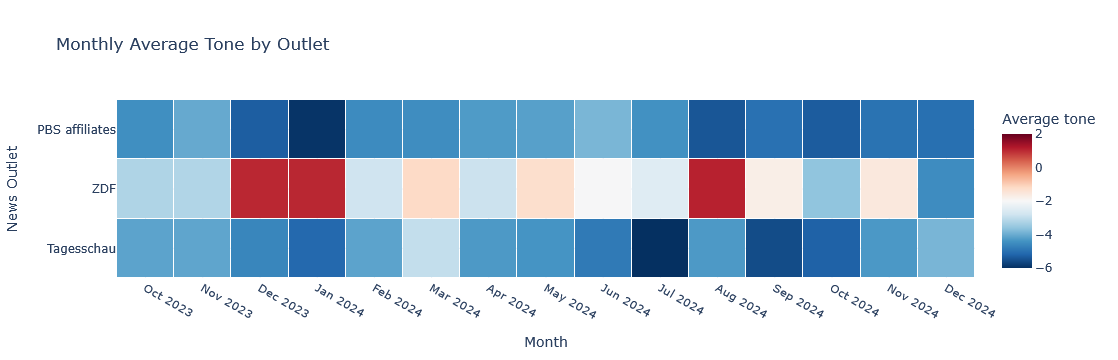

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
import plotly.graph_objects as go

path = Path(r'tagesschau_zdf_pbs_foxnews_bild_gkg_partitioned_full.csv')
df = pd.read_csv(path)

def first_tone(x):
    try:
        return float(str(x).split(',')[0])
    except Exception:
        return np.nan

df['tone'] = df['V2Tone'].map(first_tone)
df['date'] = pd.to_datetime(df['DATE'].astype(str), format='%Y%m%d%H%M%S', errors='coerce')

# news outlets
pbs_affiliates = {'pbs.org', 'kpbs.org', 'nhpbs.org', 'azpbs.org'}

def outlet_group(src):
    if src == 'tagesschau.de':
        return 'Tagesschau'
    if src == 'zdf.de':
        return 'ZDF'
    if src in pbs_affiliates:
        return 'PBS affiliates'
    return None

df['outlet_group'] = df['SourceCommonName'].map(outlet_group)

# filtering Israel-Palestine articles
url_col = 'url' if 'url' in df.columns else 'DocumentIdentifier'

keywords = [
    "gaza", "palästina", "israel", "hamas", "palestine", "rafah",
    "Zwei-Staaten-Lösung", "two-state solution", "hamas-tunnel",
    "idf", "israel defense forces", "israelische verteidigungskräfte"
]

pattern = "|".join(keywords)

topic_mask = df[url_col].astype(str).str.contains(
    pattern,
    case=False,
    na=False,
    regex=True
)

rq1 = df[df['outlet_group'].notna() & topic_mask].copy()
rq1 = rq1.dropna(subset=['date', 'tone'])

# filtering the data
rq1 = rq1[(rq1['date'] >= '2023-10-08') & (rq1['date'] <= '2024-12-31')].copy()

rq1['month'] = rq1['date'].dt.to_period('M').astype(str)

# avg tone (monthly)
heatmap_data = (
    rq1.groupby(['outlet_group', 'month'])['tone']
       .mean()
       .reset_index()
       .pivot(index='outlet_group', columns='month', values='tone')
)

# article counts (monthly)
count_data = (
    rq1.groupby(['outlet_group', 'month'])
       .size()
       .reset_index(name='article_count')
       .pivot(index='outlet_group', columns='month', values='article_count')
)

row_order = ['Tagesschau', 'ZDF', 'PBS affiliates']
heatmap_data = heatmap_data.reindex(row_order)
count_data = count_data.reindex(row_order)

col_order = sorted(heatmap_data.columns)
heatmap_data = heatmap_data.reindex(col_order, axis=1)
count_data = count_data.reindex(col_order, axis=1)

pretty_months = [pd.to_datetime(m).strftime('%b %Y') for m in col_order]

customdata = np.dstack([count_data.values])

max_negative = -6
max_positive = 2

fig = go.Figure(data=go.Heatmap(
    z=heatmap_data.values,
    x=pretty_months,
    y=heatmap_data.index,
    colorscale='RdBu_r',
    zmid=0,
    zmin=max_negative,
    zmax=max_positive,
    xgap=1,
    ygap=1,
    customdata=customdata,
    hovertemplate=(
        "Outlet: %{y}<br>"
        "Month: %{x}<br>"
        "Average tone: %{z:.2f}<br>"
        "Article count: %{customdata[0]}<extra></extra>"
    ),
    colorbar=dict(title='Average tone')
))

fig.update_layout(
    title='Monthly Average Tone by Outlet',
    xaxis_title='Month',
    yaxis_title='News Outlet',
    template='plotly_white'
)

fig.show()

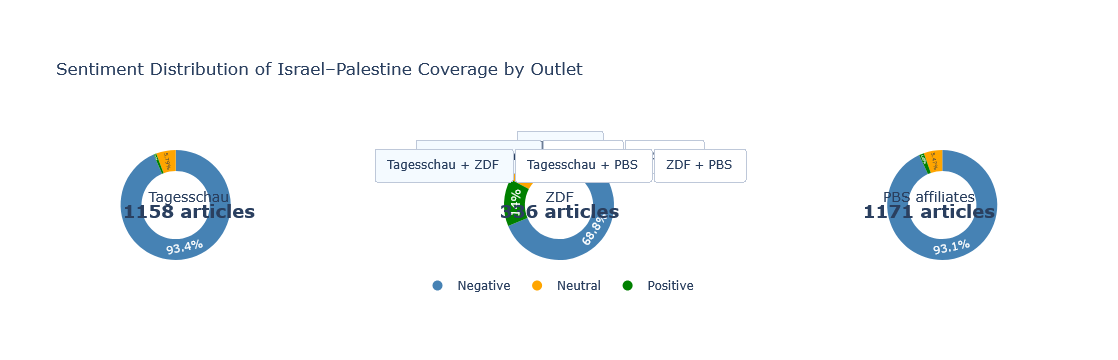

In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
import plotly.graph_objects as go
from plotly.subplots import make_subplots

path = Path(r'tagesschau_zdf_pbs_foxnews_bild_gkg_partitioned_full.csv')
df = pd.read_csv(path)

def first_tone(x):
    try:
        return float(str(x).split(',')[0])
    except Exception:
        return np.nan

df['tone'] = df['V2Tone'].map(first_tone)
df['date'] = pd.to_datetime(df['DATE'].astype(str), format='%Y%m%d%H%M%S', errors='coerce')

pbs_affiliates = {'pbs.org', 'kpbs.org', 'nhpbs.org', 'azpbs.org'}

def outlet_group(src):
    if src == 'tagesschau.de': return 'Tagesschau'
    if src == 'zdf.de': return 'ZDF'
    if src in pbs_affiliates: return 'PBS affiliates'
    return None

df['outlet_group'] = df['SourceCommonName'].map(outlet_group)

# filtering Israel-Palestine articles
url_col = 'url' if 'url' in df.columns else 'DocumentIdentifier'
keywords = ["gaza", "palästina", "israel", "hamas", "palestine", "rafah", "idf"]
pattern = "|".join(keywords)

topic_mask = df[url_col].astype(str).str.contains(pattern, case=False, na=False, regex=True)
rq1 = df[df['outlet_group'].notna() & topic_mask].copy()
rq1 = rq1.dropna(subset=['date', 'tone'])
rq1 = rq1[(rq1['date'] >= '2023-10-08') & (rq1['date'] <= '2024-12-31')].copy()

def tone_category(x):
    if x < -1: return 'Negative'
    elif x > 1: return 'Positive'
    return 'Neutral'

rq1['tone_category'] = rq1['tone'].apply(tone_category)

outlet_order = ['Tagesschau', 'ZDF', 'PBS affiliates']
sentiment_order = ['Negative', 'Neutral', 'Positive']
sentiment_colors = {'Negative': 'steelblue', 'Neutral': 'orange', 'Positive': 'green'}

# Coordinates for the centers of the three subplots (in paper units 0 to 1)
annotation_x = {
    'Tagesschau': 0.157,
    'ZDF': 0.500,
    'PBS affiliates': 0.843
}

def sentiment_counts_for(outlet_name):
    return rq1[rq1['outlet_group'] == outlet_name]['tone_category'].value_counts().reindex(sentiment_order, fill_value=0)

sentiment_counts_dict = {outlet: sentiment_counts_for(outlet) for outlet in outlet_order}
outlet_totals = {outlet: int(sentiment_counts_dict[outlet].sum()) for outlet in outlet_order}

def build_annotations(visible_outlets):
    """Creates annotations only for the outlets currently toggled on."""
    annotations = []
    for outlet in visible_outlets:
        annotations.append(
            dict(
                text=(
                    f"<span style='font-size:14px'>{outlet}</span>"
                    f"<br><span style='font-size:18px'><b>{outlet_totals[outlet]} articles</b></span>"
                ),
                x=annotation_x[outlet], # Map text to the correct donut position
                y=0.5,                  # Perfectly centered vertically
                showarrow=False,
                xref="paper",
                yref="paper",
                xanchor='center',
                yanchor='middle',
                align='center'
            )
        )
    return annotations

fig = make_subplots(
    rows=1, cols=3,
    specs=[[{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}]]
)

# donut traces (Indices 0, 1, 2)
for i, outlet in enumerate(outlet_order, start=1):
    counts = sentiment_counts_dict[outlet]
    fig.add_trace(
        go.Pie(
            labels=sentiment_order,
            values=counts.values,
            hole=0.62,
            sort=False,
            marker=dict(colors=[sentiment_colors[s] for s in sentiment_order]),
            textinfo='percent',
            textposition='inside',
            name=outlet,
            showlegend=False
        ),
        row=1, col=i
    )

# dummy legend traces (Indices 3, 4, 5)
for sentiment in sentiment_order:
    fig.add_trace(
        go.Scatter(
            x=[None], y=[None], mode='markers',
            marker=dict(size=10, color=sentiment_colors[sentiment]),
            name=sentiment, showlegend=True
        )
    )

# buttons
button_configs = [
    ("All outlets",       [True,  True,  True],  ['Tagesschau', 'ZDF', 'PBS affiliates']),
    ("Tagesschau only",   [True,  False, False], ['Tagesschau']),
    ("ZDF only",          [False, True,  False], ['ZDF']),
    ("PBS only",          [False, False, True],  ['PBS affiliates']),
    ("Tagesschau + ZDF",  [True,  True,  False], ['Tagesschau', 'ZDF']),
    ("Tagesschau + PBS",  [True,  False, True],  ['Tagesschau', 'PBS affiliates']),
    ("ZDF + PBS",         [False, True,  True],  ['ZDF', 'PBS affiliates']),
]

buttons = []
for label, visible_donuts, visible_outlets in button_configs:
    # keep dummy legend traces (the last 3) visible
    visible_all = visible_donuts + [True, True, True]
    buttons.append(
        dict(
            label=label,
            method='update',
            args=[
                {'visible': visible_all},
                {'annotations': build_annotations(visible_outlets)}
            ]
        )
    )

fig.update_layout(
    title='Sentiment Distribution of Israel–Palestine Coverage by Outlet',
    template='plotly_white',
    margin=dict(t=150, b=100, l=20, r=20),
    annotations=build_annotations(outlet_order),
    updatemenus=[
        dict(type='buttons', direction='right', buttons=[buttons[0]], x=0.5, xanchor='center', y=1.18),
        dict(type='buttons', direction='right', buttons=buttons[1:4], x=0.5, xanchor='center', y=1.10),
        dict(type='buttons', direction='right', buttons=buttons[4:], x=0.5, xanchor='center', y=1.02)
    ],
    legend=dict(orientation='h', x=0.5, xanchor='center', y=-0.1)
)

fig.update_xaxes(visible=False)
fig.update_yaxes(visible=False)

fig.show()